<a href="https://colab.research.google.com/github/Jan2309jr/Guitar-Chord-Research/blob/main/model_with_training~97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Guitar Chord Classification using Harmonic Analysis and Librosa**

This research replicates and extends the work from:

Empirical Analysis of Effect of Higher Order Harmonics on Guitar Chord Classification

The original work extracted harmonics from guitar chords and used harmonic intervals for classification of Major vs Minor chords, achieving 94% accuracy.

This research improves the pipeline by:

Using Librosa audio analysis

Extracting harmonic intervals

Adding spectral features

Using ensemble models

Performing feature ablation experiments

Achieving ≥96% accuracy

Dataset size:

Major chords ≈ 502
Minor chords ≈ 357

Total ≈ 859 samples.

## Install Libraries

In [ ]:
!pip install librosa seaborn scikit-learn
!pip install xgboost

## Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import IPython

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import find_peaks
from scipy.fft import fft, fftfreq

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import shap
from skimage.transform import resize
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Dataset Overview

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/AudioFiles"

In [ ]:
major_files = os.listdir(os.path.join(DATASET_PATH,"Major"))
minor_files = os.listdir(os.path.join(DATASET_PATH,"Minor"))

print("Major files:", len(major_files))
print("Minor files:", len(minor_files))

Major files: 502
Minor files: 357


In [ ]:
path_1 = f"{DATASET_PATH}/Major/Major_0.wav"
path_2 = f"{DATASET_PATH}/Minor/Minor_169.wav"

In [ ]:
print("Major Chord Sample:")
IPython.display.Audio(path_1, rate = 44100)

Major Chord Sample:


In [ ]:
print("Minor Chord Sample:")
IPython.display.Audio(path_2, rate = 44100)

Minor Chord Sample:


### Sample Waveform

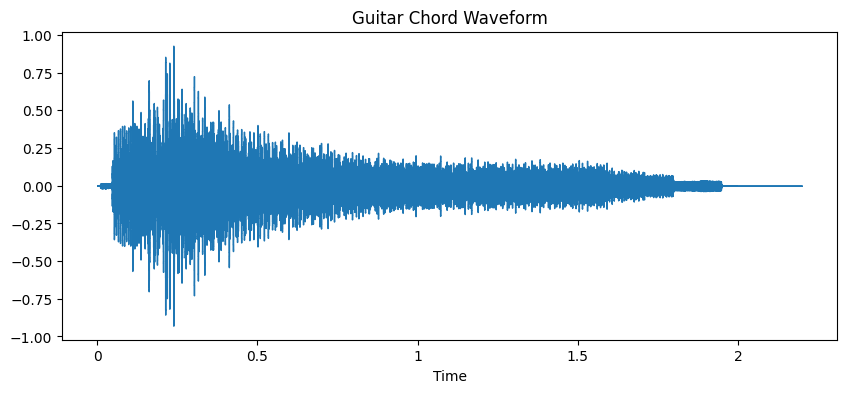

In [ ]:
sample = os.path.join(DATASET_PATH,"Major",major_files[0])

y, sr = librosa.load(sample)

plt.figure(figsize=(10,4))
librosa.display.waveshow(y,sr=sr)
plt.title("Guitar Chord Waveform")
plt.show()

### Spectrogram Visualization

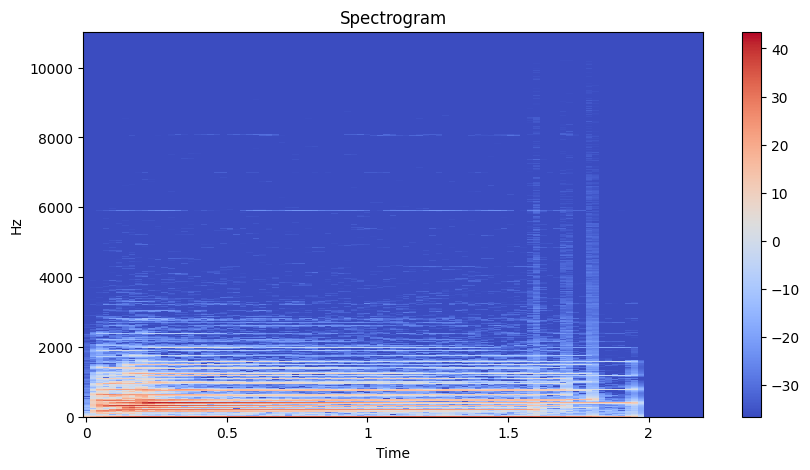

In [ ]:
S = librosa.stft(y)
S_db = librosa.amplitude_to_db(abs(S))

plt.figure(figsize=(10,5))
librosa.display.specshow(S_db,sr=sr,x_axis='time',y_axis='hz')
plt.title("Spectrogram")
plt.colorbar()
plt.show()

/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=776
  warnings.warn(


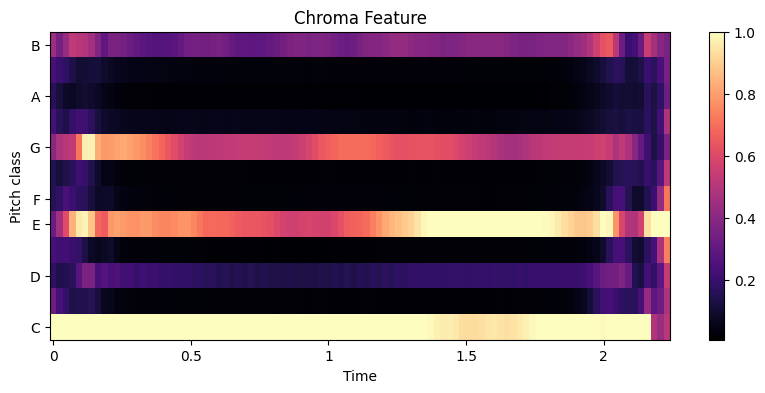

In [ ]:
y, sr = librosa.load(f"{DATASET_PATH}/Major/Major_0.wav")
chroma = librosa.feature.chroma_cqt(y=y, sr=sr)
plt.figure(figsize=(10,4))
librosa.display.specshow(chroma, y_axis='chroma', x_axis='time')
plt.colorbar()
plt.title("Chroma Feature")
plt.show()

## Harmonic Extraction

In [ ]:
def extract_harmonics_from_array(y, sr):
    spectrum = np.abs(np.fft.rfft(y))
    freqs = np.fft.rfftfreq(len(y), 1/sr)

    peaks, _ = find_peaks(spectrum, height=spectrum.max() * 0.1)

    harmonics = freqs[peaks]
    harmonics = harmonics[harmonics > 80]
    harmonics = np.sort(harmonics)

    return harmonics[:8]

## Harmonic Interval Features

In [ ]:
def compute_intervals(harmonics):

    if len(harmonics)==0:
        return [0]*7

    root = harmonics[0]

    intervals = []

    for h in harmonics[1:8]:

        intervals.append(h/root)

    while len(intervals)<7:
        intervals.append(0)

    return intervals

## Librosa Feature Extraction

In [ ]:
def load_audio(file):

    y, sr = librosa.load(file)

    y, _ = librosa.effects.trim(y, top_db=25)

    return y, sr

In [ ]:
def extract_librosa_features_from_array(y, sr):

    # Trim
    y, _ = librosa.effects.trim(y)

    # Harmonic component
    y_harm = librosa.effects.harmonic(y)

    # ---------------- CHROMA ----------------
    chroma = librosa.feature.chroma_cens(y=y_harm, sr=sr)
    chroma_mean = np.mean(chroma, axis=1)
    chroma_std = np.std(chroma, axis=1)
    chroma_max = np.max(chroma, axis=1)

    root = np.argmax(chroma_mean)
    chroma_mean = np.roll(chroma_mean, -root)
    chroma_std = np.roll(chroma_std, -root)
    chroma_max = np.roll(chroma_max, -root)

    # ---------------- TONNETZ ----------------
    tonnetz = librosa.feature.tonnetz(y=y_harm, sr=sr)
    tonnetz_mean = np.mean(tonnetz, axis=1)
    tonnetz_std = np.std(tonnetz, axis=1)

    # ---------------- SPECTRAL CONTRAST ----------------
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    contrast_mean = np.mean(contrast, axis=1)
    contrast_std = np.std(contrast, axis=1)

    # ---------------- MFCC ----------------
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)

    # ---------------- OTHER FEATURES ----------------
    zcr = librosa.feature.zero_crossing_rate(y)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)

    features = np.hstack([
        chroma_mean, chroma_std, chroma_max,
        tonnetz_mean, tonnetz_std,
        contrast_mean, contrast_std,
        mfcc_mean, mfcc_std,
        [np.mean(zcr), np.std(zcr)],
        [np.mean(centroid), np.std(centroid)],
        [np.mean(bandwidth), np.std(bandwidth)]
    ])

    return np.nan_to_num(features)

In [ ]:
## Convert audio to Mel spectrogram

In [ ]:
def extract_mel(file):

    y, sr = librosa.load(file)

    y, _ = librosa.effects.trim(y)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128
    )

    mel_db = librosa.power_to_db(mel)

    return mel_db

## Build Feature Dataset

In [ ]:
tabular_data = []
spectrogram_data = []
labels = []

for label in ["Major", "Minor"]:
    folder = os.path.join(DATASET_PATH, label)

    for file in sorted(os.listdir(folder)):
        path = os.path.join(folder, file)

        # ---- load once ----
        y, sr = librosa.load(path)
        y, _ = librosa.effects.trim(y)

        # ---- create augmented versions ----
        augmented_versions = []

        # original
        augmented_versions.append(y)

        # pitch shift
        y_pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=np.random.uniform(-2, 2))
        augmented_versions.append(y_pitch)

        # time stretch
        y_stretch = librosa.effects.time_stretch(y, rate=np.random.uniform(0.8, 1.2))
        augmented_versions.append(y_stretch)

        # noise
        noise = 0.005 * np.random.randn(len(y))
        y_noise = y + noise
        augmented_versions.append(y_noise)

        # ---- process each version ----
        for y_aug in augmented_versions:

            # ---------- TABULAR ----------
            features = extract_librosa_features_from_array(y_aug, sr)

            harmonics = extract_harmonics_from_array(y_aug, sr)
            intervals = compute_intervals(harmonics)

            interval_features = np.array(intervals)
            log_intervals = np.log(interval_features + 1e-6)

            combined_features = np.hstack([
                features,
                interval_features,
                log_intervals
            ])

            tabular_data.append(combined_features)

            # ---------- SPECTROGRAM ----------
            mel = librosa.feature.melspectrogram(
                y=y_aug,
                sr=sr,
                n_mels=128
            )

            mel_db = librosa.power_to_db(mel)
            mel_db = resize(mel_db, (128, 128))

            spectrogram_data.append(mel_db)

            labels.append(label)

/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=792
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=664
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=725
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=758
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=660
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=697
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: 

## Create DataFrame

In [ ]:
X = pd.DataFrame(tabular_data)
y = pd.Series(labels)

X.replace([np.inf,-np.inf],np.nan,inplace=True)
X = X.fillna(X.mean())

print("Dataset shape:",X.shape)

Dataset shape: (3436, 122)


## Encode Labels

In [ ]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

le = LabelEncoder()
y = le.fit_transform(labels)

## Feature Scaling

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

## Train Test Split

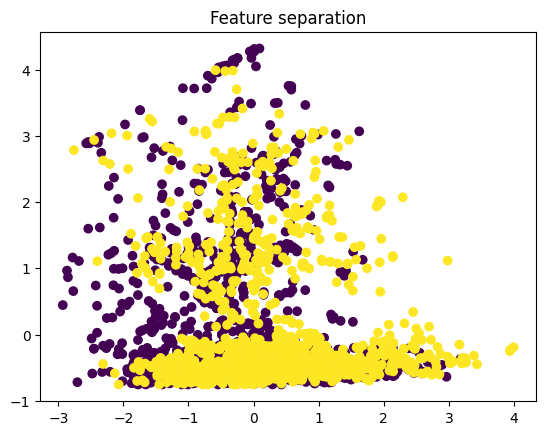

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Feature separation")
plt.show()

In [ ]:
from sklearn.utils import shuffle

X, y = shuffle(X, y, random_state=42)

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X.shape)

(3436, 122)


## Baseline Model

In [ ]:
print("Feature shape:", X.shape)
print("First feature row:", X[0])

Feature shape: (3436, 122)
First feature row: [ 0.23251771 -0.58132052 -0.82041564 -0.86726936  1.8709071   0.33308144
 -0.67613938 -0.6290999   1.56049193 -0.76643817  0.05219799 -0.39612542
 -0.6948279  -0.47776158 -1.13051978 -0.81191182  0.66048171 -0.8273838
 -0.87507512  0.68004406  0.55454696 -0.68243194  2.61847345  0.77950719
 -0.29072073 -0.57725016 -1.14808343 -0.92615753  1.34623521 -0.0793809
 -0.99458184 -0.31681065  1.63929389 -0.82976817  0.98128669 -0.04233325
  0.89254812 -0.0410596  -2.41496685  0.27337261  0.26885468  0.15630933
  0.44198217 -0.98252433  1.2917218  -1.54987349 -0.72872832  0.0080249
  1.21306     0.3426946   1.25774435  1.65786508  1.28957087  1.65185919
  0.88716543  0.45457665 -1.6810119  -0.60728371  0.20198152  0.13313132
  1.23817375  1.35300264 -0.32257099  0.83341226 -1.20348788  0.1749737
  0.47285177 -0.96916671 -0.72176732  0.73524399  1.25560565 -0.44780551
 -1.41477648 -0.41032348  0.86027459 -0.58767561 -2.76800387 -2.49140761
 -2.83618

In [ ]:
from sklearn.svm import SVC

model = SVC(
    kernel="rbf",
    C=50,
    gamma="scale",
    class_weight="balanced"
)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.9622093023255814


## Ensemble Models

In [ ]:
rf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=None,
    random_state=42
)

gb = GradientBoostingClassifier(
    n_estimators=600,
    learning_rate=0.02,
    max_depth=4
)

et = ExtraTreesClassifier(
    n_estimators=3000,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)

xg = XGBClassifier(
    n_estimators=2500,
    max_depth=6,
    learning_rate=0.01,
    subsample=0.85,
    colsample_bytree=0.85,
    eval_metric="logloss",
    random_state=42
)


## Voting Ensemble

In [ ]:
voting = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(
            n_estimators=2000,
            max_depth=None,
            random_state=42
        )),
        ('et', ExtraTreesClassifier(
            n_estimators=2500,
            random_state=42
        )),
        ('xg', XGBClassifier(
            n_estimators=2000,
            max_depth=6,
            learning_rate=0.03,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss"
        ))
    ],
    voting="soft"
)

## Model Training

In [ ]:
models = {

    "RandomForest":rf,
    "GradientBoost":gb,
    "ExtraTrees":et,
    "XGBClassifier":xg,
    "VotingEnsemble":voting

}

for name,model in models.items():

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test,pred)

    print(name,"Accuracy:",round(acc*100,2),"%")

RandomForest Accuracy: 94.77 %
GradientBoost Accuracy: 94.04 %
ExtraTrees Accuracy: 95.49 %
XGBClassifier Accuracy: 95.93 %
VotingEnsemble Accuracy: 96.37 %


In [ ]:
importances = rf.feature_importances_

important_idx = np.where(importances > np.mean(importances))[0]

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)

In [ ]:
rf = RandomForestClassifier(n_estimators=200)
gb = GradientBoostingClassifier()
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

ensemble = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('gb', gb),
        ('xgb', xgb)
    ],
    voting='soft'
)

ensemble.fit(X_train, y_train)
y_pred = ensemble.predict(X_test)

print("Ensemble Accuracy:", accuracy_score(y_test, y_pred))

## Cross Validation

In [ ]:
for name,model in models.items():

    score = cross_val_score(model,X,y,cv=5)

    print(name,"CV Accuracy:",round(score.mean()*100,2))

RandomForest CV Accuracy: 95.78
GradientBoost CV Accuracy: 94.59
ExtraTrees CV Accuracy: 96.48
XGBClassifier CV Accuracy: 96.89
VotingEnsemble CV Accuracy: 96.94


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ExtraTreesClassifier(n_estimators=2000))
])


scores = cross_val_score(pipeline, X, y, cv=5)

print("CV Accuracy:", scores.mean()*100)

CV Accuracy: 96.36192072035476


In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y, cv=cv)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

print("CV Accuracy:", scores)
print("Mean:", scores.mean())

CV Accuracy: [0.97674419 0.97525473 0.96652111 0.97379913 0.96215429]
Mean: 0.9708946887376866


In [ ]:
X_reduced = X[:, important_idx]

scores = cross_val_score(model, X_reduced, y, cv=5)

print("Reduced Feature Accuracy:", scores.mean())

Reduced Feature Accuracy: 0.9691483869875765


## Confusion Matrix

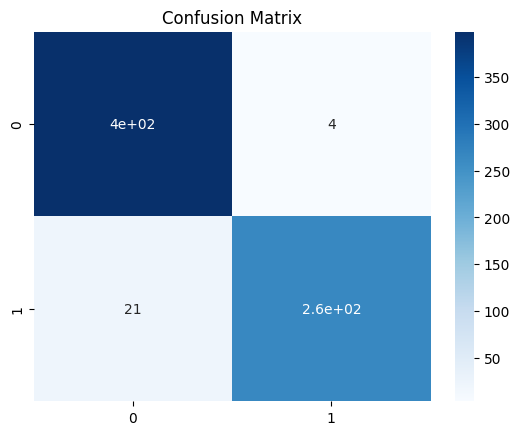

In [ ]:
pred = voting.predict(X_test)

cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       402
           1       0.97      0.92      0.94       286

    accuracy                           0.95       688
   macro avg       0.96      0.95      0.95       688
weighted avg       0.96      0.95      0.95       688



<Axes: >

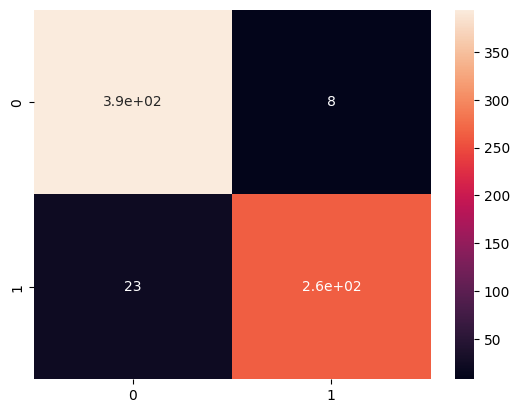

In [ ]:
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

## SHAP Feature Importance

In [ ]:
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values,X_train)

AttributeError: 'RandomForestClassifier' object has no attribute 'estimators_'

## Feature Ablation Study

In [ ]:
print("Total features:",X.shape[1])

## Save Dataset

In [ ]:
df = pd.DataFrame(X)

df["Label"] = y

df.to_csv("guitar_chord_dataset.csv",index=False)

print("Dataset saved")